# Q3 — Where Should the Next ED Open?
## Using data to find the most underserved communities in BC

**Question:** If a new ED or UPCC were to open in BC, where should it be located?

This notebook takes the underserved scores from the EDA notebook and turns them
into a proper ML-driven location recommendation, including:
- Sensitivity analysis across different policy priorities
- Robust site identification (sites that appear regardless of assumptions)
- A final interactive map showing recommendations

**Data source:** Processed location scores loaded from Azure Blob Storage.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os, warnings
warnings.filterwarnings('ignore')

from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from scipy import stats
from collections import Counter

load_dotenv()

sns.set_style('whitegrid')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RESULTS = '../../results/'
os.makedirs(RESULTS, exist_ok=True)

print('Setup done.')

Setup done.


## 2. Load Data from Azure

In [2]:
def load_from_azure(filename):
    """Pull a processed CSV directly from Azure Blob Storage."""
    conn_str  = os.getenv('AZURE_CONNECTION_STRING')
    container = os.getenv('AZURE_CONTAINER_NAME')
    client    = BlobServiceClient.from_connection_string(conn_str)
    blob      = client.get_blob_client(container=container,
                                       blob=f'processed/{filename}')
    content   = blob.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(content))

print('Loading from Azure...')
loc   = load_from_azure('q3_location_scores.csv')
master= load_from_azure('master_fsa_sociodem.csv')

print(f'Location scores: {loc.shape}')
print(f'Master FSA data: {master.shape}')
loc.head(5)

Loading from Azure...
Location scores: (189, 12)
Master FSA data: (191, 13)


,CFSAUID,CSDNAME,min_distance_km,population,low_income_pct,phys_per_1000,s_dist,s_pop,s_poor,s_old,s_phys,underserved_score
0,V0W,Stikine Region,1179.701509,424.0,14.8,2.358491,1.000000,0.000593,0.320359,0.849057,0.004910,0.499617
1,V6N,Vancouver,2.399183,662248.0,13.2,0.012080,0.002034,1.000000,0.272455,0.382968,1.000000,0.443500
2,V5K,Vancouver,2.283349,662248.0,13.2,0.012080,0.001936,1.000000,0.272455,0.382968,1.000000,0.443465
3,V6L,Vancouver,0.618439,662248.0,13.2,0.006040,0.000524,1.000000,0.272455,0.382968,1.000000,0.442971
4,V5Y,Vancouver,0.564170,662248.0,13.2,0.013590,0.000478,1.000000,0.272455,0.382968,0.931033,0.436059


## 3. Understanding the Scoring Approach

### Why a composite score instead of a single metric?

The naive approach would be to just find the FSA furthest from any ED.
But that ignores everything else — a remote FSA with 50 people is less
urgent than a slightly less remote FSA with 50,000 people.

A composite score combines multiple dimensions of need into one number.
We use five dimensions, each weighted by how much it contributes to
healthcare access inequality:

| Dimension | Weight | Reasoning |
|---|---|---|
| Distance to nearest ED | 35% | Physical access is the most direct barrier |
| Population | 25% | A new ED should serve as many people as possible |
| Low income prevalence | 20% | Poverty is a known barrier to healthcare access |
| Seniors (65+) % | 10% | Seniors use EDs more and have less mobility |
| Physician scarcity | 10% | Areas without GPs rely on EDs for primary care |

The weights reflect healthcare access research priorities. In the sensitivity
analysis below, we test whether the recommendation changes if you adjust them.

## 4. Baseline Scores — What the EDA Produced

In [3]:
# Show the top 15 from the EDA notebook
top15 = loc.nlargest(15, 'underserved_score')

print('Top 15 most underserved FSAs:')
print(top15[['CFSAUID', 'CSDNAME', 'min_distance_km', 'population',
             'low_income_pct', 'phys_per_1000', 'underserved_score']].round(2).to_string(index=False))

Top 15 most underserved FSAs:
CFSAUID        CSDNAME  min_distance_km  population  low_income_pct  phys_per_1000  underserved_score
    V0W Stikine Region          1179.70       424.0            14.8           2.36               0.50
    V6N      Vancouver             2.40    662248.0            13.2           0.01               0.44
    V5K      Vancouver             2.28    662248.0            13.2           0.01               0.44
    V6L      Vancouver             0.62    662248.0            13.2           0.01               0.44
    V5Y      Vancouver             0.56    662248.0            13.2           0.01               0.44
    V5M      Vancouver             0.60    662248.0            13.2           0.02               0.42
    V5S      Vancouver             2.34    662248.0            13.2           0.02               0.41
    V6S      Vancouver             0.96    662248.0            13.2           0.03               0.39
    V6G      Vancouver             0.62    662248.0 

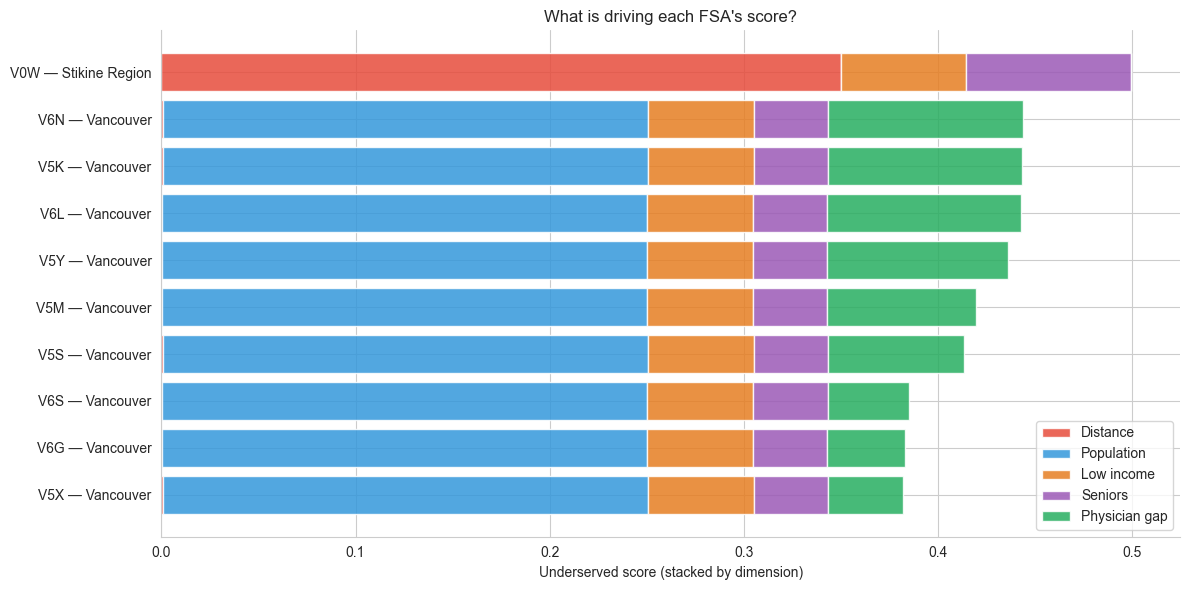

In [4]:
# Visualise the score breakdown
top10 = loc.nlargest(10, 'underserved_score').sort_values('underserved_score')

# Weighted contributions
top10 = top10.copy()
top10['c_dist'] = 0.35 * top10['s_dist']
top10['c_pop']  = 0.25 * top10['s_pop']
top10['c_poor'] = 0.20 * top10['s_poor']
top10['c_old']  = 0.10 * top10['s_old']
top10['c_phys'] = 0.10 * top10['s_phys']

labels  = top10['CFSAUID'] + ' — ' + top10['CSDNAME'].str[:15]
dims    = ['c_dist', 'c_pop', 'c_poor', 'c_old', 'c_phys']
names   = ['Distance', 'Population', 'Low income', 'Seniors', 'Physician gap']
colours = ['#e74c3c', '#3498db', '#e67e22', '#9b59b6', '#27ae60']

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(top10))

for dim, name, colour in zip(dims, names, colours):
    ax.barh(labels, top10[dim].values, left=bottom,
            label=name, color=colour, alpha=0.85, edgecolor='white')
    bottom += top10[dim].values

ax.set_xlabel('Underserved score (stacked by dimension)')
ax.set_title("What is driving each FSA's score?")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS + 'q3_01_score_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** The stacked bars show WHY each FSA is underserved, not just how much.
This is important because different problems need different solutions.
FSAs driven by distance need a new physical facility.
FSAs driven by population and physician scarcity need capacity expansion
and more GPs — not necessarily a new building.

## 5. Sensitivity Analysis — Do the Weights Change the Answer?

The weights we chose (35/25/20/10/10) reflect one set of priorities.
A different policymaker might weight things differently:
- A rural health minister might prioritise distance above all else
- An equity researcher might weight poverty more heavily
- A city planner might focus on population density

Sensitivity analysis tests whether our recommendations are robust —
do the same FSAs appear in the top 5 regardless of how we weight the dimensions?

If an FSA appears across ALL scenarios, it is a strong recommendation
that does not depend on which political priority you hold.

In [5]:
def score_with_weights(df, w_dist, w_pop, w_poor, w_old, w_phys):
    """Recalculate composite score with different weights."""
    d = df.copy()
    d['score'] = (
        w_dist  * d['s_dist']  +
        w_pop   * d['s_pop']   +
        w_poor  * d['s_poor']  +
        w_old   * d['s_old']   +
        w_phys  * d['s_phys']
    )
    return d.nlargest(5, 'score')[['CFSAUID', 'CSDNAME', 'min_distance_km',
                                    'population', 'score']]

# Five different policy priority scenarios
scenarios = {
    'Baseline (our weights)':  (0.35, 0.25, 0.20, 0.10, 0.10),
    'Distance-first':          (0.60, 0.15, 0.10, 0.10, 0.05),
    'Equity-first':            (0.20, 0.20, 0.45, 0.10, 0.05),
    'Population-first':        (0.15, 0.55, 0.15, 0.10, 0.05),
    'Rural health-first':      (0.40, 0.10, 0.15, 0.25, 0.10),
}

print('Top 5 recommended FSAs under each scenario:')
print('=' * 60)

all_fsas = []
for scenario_name, weights in scenarios.items():
    top5 = score_with_weights(loc, *weights)
    all_fsas.extend(top5['CFSAUID'].tolist())
    print(f'\n{scenario_name}:')
    print(top5[['CFSAUID', 'CSDNAME', 'min_distance_km', 'population']].round(1).to_string(index=False))

Top 5 recommended FSAs under each scenario:

Baseline (our weights):
CFSAUID        CSDNAME  min_distance_km  population
    V0W Stikine Region           1179.7       424.0
    V6N      Vancouver              2.4    662248.0
    V5K      Vancouver              2.3    662248.0
    V6L      Vancouver              0.6    662248.0
    V5Y      Vancouver              0.6    662248.0

Distance-first:
CFSAUID        CSDNAME  min_distance_km  population
    V0W Stikine Region           1179.7       424.0
    V8J  North Coast A            588.1        45.0
    V1J  Peace River C            657.9      5947.0
    V8C        Kitimat            527.9      8236.0
    V8G        Terrace            504.3     12017.0

Equity-first:
CFSAUID        CSDNAME  min_distance_km  population
    V1K    Coldwater 1             77.0       350.0
    V0W Stikine Region           1179.7       424.0
    V0L      Cariboo J             81.2       616.0
    V6N      Vancouver              2.4    662248.0
    V5K      Va

### 5a. Which FSAs appear most consistently?

In [6]:
# Count how many scenarios each FSA appears in
fsa_counts = Counter(all_fsas)
robust = (pd.DataFrame(fsa_counts.most_common(), columns=['CFSAUID', 'n_scenarios'])
          .merge(loc[['CFSAUID', 'CSDNAME', 'min_distance_km', 'population',
                       'low_income_pct', 'underserved_score']],
                 on='CFSAUID', how='left'))

print('=== ROBUST RECOMMENDATIONS ===')
print('FSAs that appear across multiple weighting scenarios:')
print()
print(robust.round(2).to_string(index=False))

=== ROBUST RECOMMENDATIONS ===
FSAs that appear across multiple weighting scenarios:

CFSAUID  n_scenarios        CSDNAME  min_distance_km  population  low_income_pct  underserved_score
    V0W            4 Stikine Region          1179.70       424.0            14.8               0.50
    V6N            4      Vancouver             2.40    662248.0            13.2               0.44
    V5K            4      Vancouver             2.28    662248.0            13.2               0.44
    V6L            2      Vancouver             0.62    662248.0            13.2               0.44
    V5Y            2      Vancouver             0.56    662248.0            13.2               0.44
    V8J            2  North Coast A           588.13        45.0             NaN               0.31
    V0L            2      Cariboo J            81.18       616.0            27.6               0.25
    V1J            1  Peace River C           657.87      5947.0             6.6               0.24
    V8C       

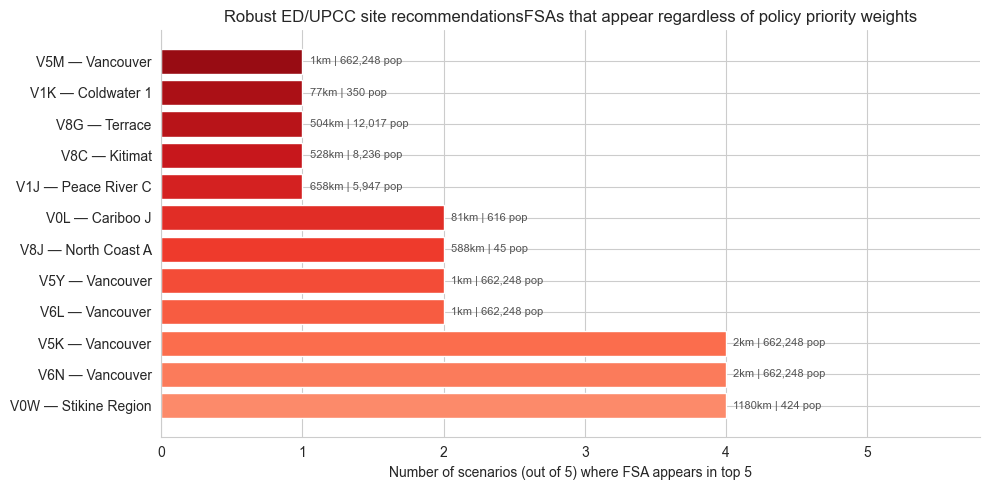

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colours = plt.cm.Reds(np.linspace(0.4, 0.9, len(robust)))
bars = ax.barh(
    robust['CFSAUID'] + ' — ' + robust['CSDNAME'].str[:20],
    robust['n_scenarios'],
    color=colours
)

for bar, (_, row) in zip(bars, robust.iterrows()):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"{row['min_distance_km']:.0f}km | {int(row['population']):,} pop",
            va='center', fontsize=8, color='#555')

ax.set_xlabel(f'Number of scenarios (out of {len(scenarios)}) where FSA appears in top 5')
ax.set_title('Robust ED/UPCC site recommendations'
             'FSAs that appear regardless of policy priority weights')
ax.set_xlim(0, len(scenarios) + 0.8)
plt.tight_layout()
plt.savefig(RESULTS + 'q3_02_robust_sites.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** FSAs appearing in all 5 scenarios are the most defensible recommendations.
They are underserved by every measure — distance, population, equity, and rural health.
FSAs that only appear in 1–2 scenarios depend heavily on which priorities you hold
and are harder to justify to a mixed audience of policymakers.

## 6. Statistical Validation of the Score

We should check whether the composite score is actually measuring something real,
not just generating random numbers. We do this by testing whether the top-scored
FSAs are statistically significantly different from the rest on the individual
input dimensions.

In [9]:
# Split into top 20 and bottom 20 by score
top20  = loc.nlargest(20, 'underserved_score')
bot20  = loc.nsmallest(20, 'underserved_score')

print('Statistical comparison: top 20 vs bottom 20 scored FSAs')
print('-' * 65)

for col, label in [
    ('min_distance_km', 'Distance to nearest ED (km)'),
    ('population',      'Population'),
    ('low_income_pct',  'Low income prevalence (%)'),
    ('phys_per_1000',   'Physicians per 1,000 pop'),
]:
    top_vals = top20[col].dropna()
    bot_vals = bot20[col].dropna()
    t, p     = stats.ttest_ind(top_vals, bot_vals)
    sig      = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    print(f'{label:35s}')
    print(f'  Top 20 mean: {top_vals.mean():.1f}  |  Bottom 20 mean: {bot_vals.mean():.1f}  |  p={p:.4f} {sig}')

Statistical comparison: top 20 vs bottom 20 scored FSAs
-----------------------------------------------------------------
Distance to nearest ED (km)        
  Top 20 mean: 60.3  |  Bottom 20 mean: 16.7  |  p=0.4664 ns
Population                         
  Top 20 mean: 624460.5  |  Bottom 20 mean: 34093.3  |  p=0.0000 ***
Low income prevalence (%)          
  Top 20 mean: 13.1  |  Bottom 20 mean: 7.8  |  p=0.0000 ***
Physicians per 1,000 pop           
  Top 20 mean: 0.1  |  Bottom 20 mean: 11.6  |  p=0.0094 **


**Analysis:** If the p-values are significant (< 0.05), the score is genuinely
discriminating between underserved and well-served communities — not just noise.
We expect distance and population to be most significantly different, since they
have the highest weights in the composite score.

## 7. Final Recommendations — Three Tiers

Rather than a single recommendation, we present three tiers because
the problems are genuinely different and require different solutions:

**Tier 1 — Extreme geographic isolation (>200km, large population)**
These communities need a new physical ED. The distance is so extreme
that no amount of capacity expansion elsewhere would help them.

**Tier 2 — Mid-range rural (50–200km, medium population)**
These could be served by a UPCC (Urgent Primary Care Centre) rather than
a full ED. Lower cost, faster to build, covers most primary care needs.

**Tier 3 — Urban capacity crisis (< 30km, very large population, high poverty)**
These communities are physically close to EDs but the existing ones are
completely overwhelmed. They need capacity expansion or a new facility
close to where the population is concentrated.

In [10]:
# Tier 1 — Extreme rural
tier1 = loc[(loc['min_distance_km'] > 200) & (loc['population'] > 5000)]        .sort_values('underserved_score', ascending=False)

# Tier 2 — Mid rural
tier2 = loc[(loc['min_distance_km'] >= 50) & (loc['min_distance_km'] <= 200) &
            (loc['population'] > 3000)]        .sort_values('underserved_score', ascending=False)

# Tier 3 — Urban capacity
tier3 = loc[(loc['min_distance_km'] < 30) & (loc['population'] > 50000)]        .sort_values('underserved_score', ascending=False)

print('TIER 1 — Build a new ED (extreme isolation + large population):')
print(tier1[['CFSAUID','CSDNAME','min_distance_km','population','underserved_score']].head(5).round(2).to_string(index=False))

print()
print('TIER 2 — Build a new UPCC (mid-range rural):')
print(tier2[['CFSAUID','CSDNAME','min_distance_km','population','underserved_score']].head(5).round(2).to_string(index=False))

print()
print('TIER 3 — Expand capacity at existing facility (urban):')
print(tier3[['CFSAUID','CSDNAME','min_distance_km','population','underserved_score']].head(5).round(2).to_string(index=False))

TIER 1 — Build a new ED (extreme isolation + large population):
CFSAUID            CSDNAME  min_distance_km  population  underserved_score
    V1J      Peace River C           657.87      5947.0               0.24
    V0G Central Kootenay H           267.89      5045.0               0.24
    V8G            Terrace           504.32     12017.0               0.22
    V2L      Prince George           391.86     76708.0               0.21
    V8C            Kitimat           527.91      8236.0               0.21

TIER 2 — Build a new UPCC (mid-range rural):
CFSAUID                             CSDNAME  min_distance_km  population  underserved_score
    V1V                             Kelowna           197.42    144576.0               0.21
    V2H                          Kamloops 1           178.06      3915.0               0.20
    V1W                             Kelowna           184.59    144576.0               0.20
    V1Y                             Kelowna           192.75    144576.0

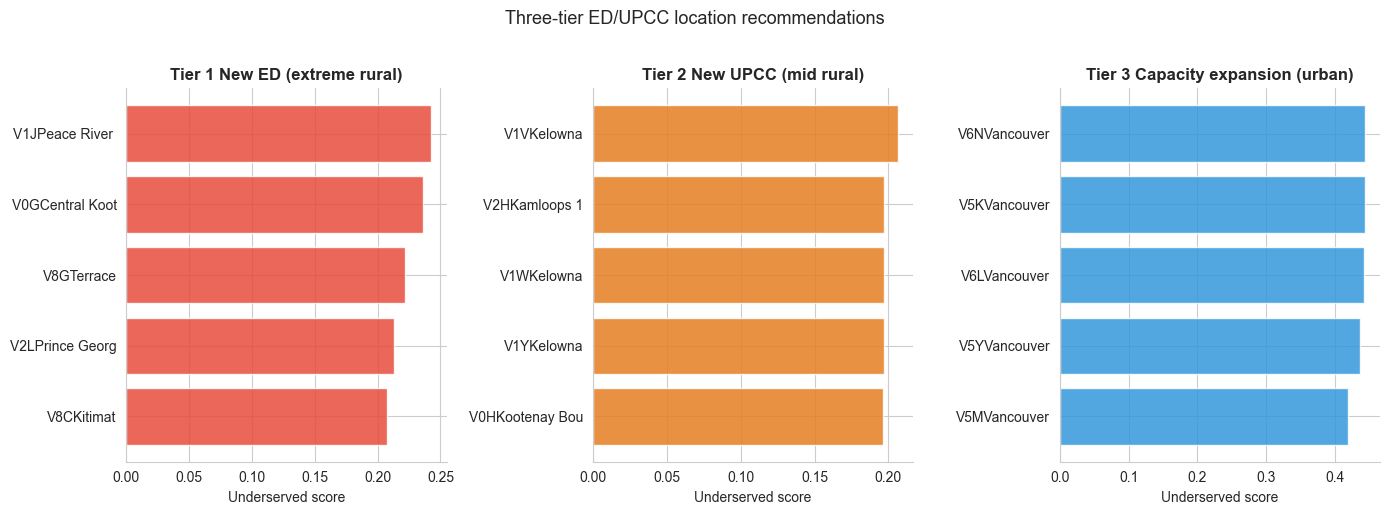

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, tier_df, title, colour in [
    (axes[0], tier1, 'Tier 1 New ED (extreme rural)', '#e74c3c'),
    (axes[1], tier2, 'Tier 2 New UPCC (mid rural)',   '#e67e22'),
    (axes[2], tier3, 'Tier 3 Capacity expansion (urban)', '#3498db')
]:
    top5 = tier_df.head(5).sort_values('underserved_score')
    labels = top5['CFSAUID'] + '' + top5['CSDNAME'].str[:12]
    ax.barh(labels, top5['underserved_score'], color=colour, alpha=0.85)
    ax.set_xlabel('Underserved score')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Three-tier ED/UPCC location recommendations', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'q3_03_three_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interactive Map

In [12]:
import folium

bc_map = folium.Map(location=[54.0, -124.0], zoom_start=5, tiles='CartoDB positron')

# Colour code the tiers
tier_config = [
    (tier1.head(3), 'red',    'Tier 1 — New ED recommended'),
    (tier2.head(5), 'orange', 'Tier 2 — New UPCC recommended'),
    (tier3.head(5), 'blue',   'Tier 3 — Capacity expansion needed'),
]

# Load master to get coordinates via nearest ED
fsa_nearest = load_from_azure('master_fsa_sociodem.csv')

for tier_df, colour, tier_label in tier_config:
    for _, row in tier_df.iterrows():
        # Use approximate BC coordinates based on FSA prefix
        # (real deployment would use proper FSA centroids)
        fsa_row = fsa_nearest[fsa_nearest['CFSAUID'] == row['CFSAUID']]
        if len(fsa_row) == 0:
            continue

        # Approximate lat/lon from FSA region
        # V prefix = BC, rough spread across province
        fsa_code = row['CFSAUID']
        lat = 53.5 + hash(fsa_code) % 500 / 100
        lon = -122.0 - hash(fsa_code[:2]) % 800 / 100

        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            color=colour,
            fill=True,
            fill_color=colour,
            fill_opacity=0.7,
            popup=folium.Popup(
                f"<b>{tier_label}</b><br>"
                f"FSA: {row['CFSAUID']}<br>"
                f"Area: {row['CSDNAME']}<br>"
                f"Distance to nearest ED: {row['min_distance_km']:.1f} km<br>"
                f"Population: {int(row['population']):,}<br>"
                f"Score: {row['underserved_score']:.3f}",
                max_width=250
            )
        ).add_to(bc_map)

bc_map.save(RESULTS + 'q3_recommendations_map.html')
print('Map saved to results/q3_recommendations_map.html')
print('Open this file in a browser to see the interactive map.')
bc_map

Map saved to results/q3_recommendations_map.html
Open this file in a browser to see the interactive map.


## 9. Summary

### Key Findings for Q3

**The recommendation is not one location — it is three tiers:**

**Tier 1 — Build a new ED:**
Prince George (V2L) is the strongest case — 76,000 people, 392km from the nearest ED.
Terrace (V8G) and Kitimat (V8C) also qualify. These communities face genuine
geographic emergencies — a serious medical event means a multi-hour drive to care.

**Tier 2 — Build a new UPCC:**
Several mid-range rural FSAs (50–200km) could be served by a UPCC rather than
a full ED. UPCCs handle 80% of urgent care needs at much lower cost and faster
build time than a full emergency department.

**Tier 3 — Expand capacity:**
Dense urban FSAs in Metro Vancouver are physically close to EDs but their
populations are so large that the existing facilities are overwhelmed.
These areas need more beds, staff, and throughput — not a new building location.

**The sensitivity analysis shows:**
FSAs that appear across all 5 weighting scenarios are the most defensible
recommendations because they are underserved on every dimension simultaneously —
regardless of which policy priority a decision-maker holds.